### **WP3.3 - random forest model**

This notebook trains Random Forest comparators to test whether nonlinear tree-based models improve over logistic regression.


##### **Notebook Outline**

- **matrix load:** load the selected WP3.1 processed matrix and shared modelling metadata.
- **random forest tuning:** screen regularisation and tree-depth settings using validation PR-AUC.
- **threshold assessment:** evaluate precision, recall, F1, calibration, and confusion matrices across selected thresholds.
- **output save:** save model objects, prediction files, performance tables, and comparison workbooks.


In [ ]:
#import libraries used for random forest modelling, evaluation, saving outputs, and plotting
import sys
from pathlib import Path
import warnings
import time
from collections import Counter
import re
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse
from sklearn.calibration import calibration_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, average_precision_score, balanced_accuracy_score,
    brier_score_loss, confusion_matrix, f1_score, precision_recall_curve, precision_score,
    recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import ParameterSampler, StratifiedShuffleSplit

warnings.filterwarnings("ignore")
print(sys.executable)

/scratch/DissProject/my_env/bin/python


**Import libraries and define paths**

The model uses the processed train/test matrices created in WP3.1 and saves all Random Forest outputs into a dedicated WP3.3 folder.

In [ ]:
#set file paths and create output folders
current_path = Path.cwd().resolve()
project_path = None
for candidate_path in [current_path] + list(current_path.parents):
    if (candidate_path / "code").exists():
        project_path = candidate_path
        break
if project_path is None:
    project_path = Path("/Users/ahthini/Desktop/DissProject")
wp3_input_variant = "shap_guided_reduced_feature_set"
wp3_1_output_path = project_path / "outputs" / "WP3_1"
wp3_3_output_path = project_path / "outputs" / "WP3_3"
random_forest_output_path = wp3_3_output_path / "random_forest"
regularised_random_forest_output_path = wp3_3_output_path / "regularised_random_forest"
random_forest_output_path.mkdir(parents=True, exist_ok=True)
regularised_random_forest_output_path.mkdir(parents=True, exist_ok=True)

#use the shap-guided reduced wp3.1 processed matrices and previously selected rf settings
run_hyperparameter_screening = True
print("WP3 input variant:", wp3_input_variant)
print("WP3.1 input folder:", wp3_1_output_path)
print("WP3.3 output folder:", wp3_3_output_path)
print("Random Forest output folder:", random_forest_output_path)
print("Regularised Random Forest output folder:", regularised_random_forest_output_path)

WP3 input variant: shap_guided_reduced_feature_set
WP3.1 input folder: /scratch/DissProject/outputs/WP3_1
WP3.3 output folder: /scratch/DissProject/outputs/WP3_3
Random Forest output folder: /scratch/DissProject/outputs/WP3_3/random_forest
Regularised Random Forest output folder: /scratch/DissProject/outputs/WP3_3/regularised_random_forest


**Load WP3.1 modelling matrices**

The processed matrices already include missing value handling, numerical standardisation, and categorical one-hot encoding fitted on the training set only.

In [ ]:
#load processed matrices, labels, identifiers, and feature names created in wp3.1
#wp3_input_variant controls the processed feature matrix used as the primary modelling input.
#use "full" for the complete processed matrix, "clean_feature_audit" for leakage-cleaned features,
#"runtime_trimmed_feature_audit" for the audit-trimmed matrix, or "shap_guided_reduced_feature_set" for the primary small primary matrix.
if wp3_input_variant in ["full", "original", "complete"]:
    X_train_file = wp3_1_output_path / "t3_1_X_train_processed.npz"
    X_test_file = wp3_1_output_path / "t3_1_X_test_processed.npz"
    feature_names_file = wp3_1_output_path / "t3_1_processed_feature_names.csv"
else:
    matrix_suffix = f"_{wp3_input_variant}"
    X_train_file = wp3_1_output_path / f"t3_1_X_train_processed{matrix_suffix}.npz"
    X_test_file = wp3_1_output_path / f"t3_1_X_test_processed{matrix_suffix}.npz"
    feature_names_file = wp3_1_output_path / f"t3_1_processed_feature_names{matrix_suffix}.csv"

#backward-compatible fallback for reduced matrices created by the embedded wp3.1 feature-audit extension
if not X_train_file.exists() or not X_test_file.exists() or not feature_names_file.exists():
    wp3_feature_audit_output_path = project_path / "outputs" / "WP3_feature_audit"
    if wp3_input_variant not in ["full", "original", "complete"]:
        X_train_file = wp3_feature_audit_output_path / f"t3_1_X_train_processed{matrix_suffix}.npz"
        X_test_file = wp3_feature_audit_output_path / f"t3_1_X_test_processed{matrix_suffix}.npz"
        feature_names_file = wp3_feature_audit_output_path / f"t3_1_processed_feature_names{matrix_suffix}.csv"

missing_input_files = [path for path in [X_train_file, X_test_file, feature_names_file] if not path.exists()]
if missing_input_files:
    raise FileNotFoundError("Missing WP3 input files: " + ", ".join(str(path) for path in missing_input_files))

X_train = sparse.load_npz(X_train_file)
X_test = sparse.load_npz(X_test_file)
y_train = pd.read_csv(wp3_1_output_path / "t3_1_y_train.csv")["readmitted_30d"].astype(int)
y_test = pd.read_csv(wp3_1_output_path / "t3_1_y_test.csv")["readmitted_30d"].astype(int)
train_ids = pd.read_csv(wp3_1_output_path / "t3_1_train_ids.csv")
test_ids = pd.read_csv(wp3_1_output_path / "t3_1_test_ids.csv")
feature_names = pd.read_csv(feature_names_file)["processed_feature_name"].tolist()
class_weight_summary = pd.read_csv(wp3_1_output_path / "t3_1_class_weight_summary.csv")

print("WP3 input variant:", wp3_input_variant)
print("Training matrix file:", X_train_file)
print("Test matrix file:", X_test_file)
print("Feature names file:", feature_names_file)
print("Training matrix shape:", X_train.shape)
print("Test matrix shape:", X_test.shape)
print("Number of processed feature names:", len(feature_names))
print()
print("Training outcome distribution:")
print(y_train.value_counts())
print((y_train.value_counts(normalize=True) * 100).round(2))
print()
print("Test outcome distribution:")
print(y_test.value_counts())
print((y_test.value_counts(normalize=True) * 100).round(2))
print()
print("Class imbalance summary from WP3.1:")
print(class_weight_summary)

WP3 input variant: shap_guided_reduced_feature_set
Training matrix file: /scratch/DissProject/outputs/WP3_1/t3_1_X_train_processed_shap_guided_reduced_feature_set.npz
Test matrix file: /scratch/DissProject/outputs/WP3_1/t3_1_X_test_processed_shap_guided_reduced_feature_set.npz
Feature names file: /scratch/DissProject/outputs/WP3_1/t3_1_processed_feature_names_shap_guided_reduced_feature_set.csv
Training matrix shape: (191320, 973)
Test matrix shape: (47171, 973)
Number of processed feature names: 973

Training outcome distribution:
readmitted_30d
0    153281
1     38039
Name: count, dtype: int64
readmitted_30d
0    80.12
1    19.88
Name: proportion, dtype: float64

Test outcome distribution:
readmitted_30d
0    37852
1     9319
Name: count, dtype: int64
readmitted_30d
0    80.24
1    19.76
Name: proportion, dtype: float64

Class imbalance summary from WP3.1:
                    metric        value
0  training_negative_cases  153281.0000
1  training_positive_cases   38039.0000
2   posit

**Define reusable evaluation functions**

These functions match the WP3.2 metric definitions so Logistic Regression and Random Forest can be compared fairly later.

In [ ]:
#define helper functions for consistent model evaluation
def evaluate_binary_predictions(model_name, y_true, y_probability, threshold=0.5):
    #convert probabilities into binary predictions at the selected threshold
    y_pred = (y_probability >= threshold).astype(int)
    #extract confusion matrix counts for sensitivity and specificity
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    return {"model": model_name, "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall_sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "specificity": specificity, "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_probability),
        "pr_auc_average_precision": average_precision_score(y_true, y_probability),
        "brier_score": brier_score_loss(y_true, y_probability),
        "true_negatives": tn, "false_positives": fp, "false_negatives": fn, "true_positives": tp}

#find best threshold
def find_best_threshold(y_true, y_probability):
    #select thresholds on training predictions only to avoid tuning on the test set
    thresholds = np.linspace(0.01, 0.99, 99)
    rows = []
    #loop through each item in this feature block
    for threshold in thresholds:
        y_pred = (y_probability >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
        specificity = tn / (tn + fp) if (tn + fp) else np.nan
        precision = precision_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        rows.append({"threshold": threshold, "precision": precision, "recall_sensitivity": sensitivity,
            "precision_recall_gap": abs(precision - sensitivity), "f1_score": f1,
            "youden_index": sensitivity + specificity - 1,
            "sensitivity": sensitivity, "specificity": specificity})
    threshold_df = pd.DataFrame(rows)
    best_f1_threshold = threshold_df.sort_values("f1_score", ascending=False).iloc[0]["threshold"]
    best_youden_threshold = threshold_df.sort_values("youden_index", ascending=False).iloc[0]["threshold"]
    return threshold_df, float(best_f1_threshold), float(best_youden_threshold)

#save prediction file
def save_prediction_file(output_folder, file_name, ids, y_probability, threshold):
    #save held-out test predictions with admission identifiers for later comparative evaluation
    pred_df = ids.copy()
    pred_df["predicted_probability"] = y_probability
    pred_df["predicted_class"] = (y_probability >= threshold).astype(int)
    #save this table or artefact for later review
    pred_df.to_csv(output_folder / file_name, index=False)
    return pred_df

#add timing metrics
def add_timing_metrics(metrics, training_time_seconds, train_inference_time_seconds, test_inference_time_seconds, number_of_test_admissions):
    #attach runtime values to a model performance dictionary for later comparison
    metrics = metrics.copy()
    metrics["training_time_seconds"] = training_time_seconds
    metrics["train_inference_time_seconds"] = train_inference_time_seconds
    metrics["test_inference_time_seconds"] = test_inference_time_seconds
    metrics["test_inference_time_per_admission_ms"] = (test_inference_time_seconds / number_of_test_admissions) * 1000
    return metrics

**Create a larger Random Forest tuning subset**




In [ ]:
#create a larger stratified tuning subset for random forest hyperparameter screening; the final model is still trained later on the full training set
screening_sample_size = min(90000, X_train.shape[0])
validation_fraction = 0.25

sample_splitter = StratifiedShuffleSplit(n_splits=1, train_size=screening_sample_size, random_state=42)
sample_idx, _ = next(sample_splitter.split(np.zeros(len(y_train)), y_train))

X_screen = X_train[sample_idx]
y_screen = y_train.iloc[sample_idx].reset_index(drop=True)

validation_splitter = StratifiedShuffleSplit(n_splits=1, test_size=validation_fraction, random_state=42)
screen_train_idx, screen_val_idx = next(validation_splitter.split(np.zeros(len(y_screen)), y_screen))

X_screen_train = X_screen[screen_train_idx]
X_screen_val = X_screen[screen_val_idx]
y_screen_train = y_screen.iloc[screen_train_idx].reset_index(drop=True)
y_screen_val = y_screen.iloc[screen_val_idx].reset_index(drop=True)

print("Screening sample shape:", X_screen.shape)
print("Screening training shape:", X_screen_train.shape)
print("Screening validation shape:", X_screen_val.shape)
print("\nScreening validation outcome distribution:")
print(y_screen_val.value_counts())
print((y_screen_val.value_counts(normalize=True) * 100).round(2))

Screening sample shape: (90000, 973)
Screening training shape: (67500, 973)
Screening validation shape: (22500, 973)

Screening validation outcome distribution:
readmitted_30d
0    18027
1     4473
Name: count, dtype: int64
readmitted_30d
0    80.12
1    19.88
Name: proportion, dtype: float64


**Random Forest hyperparameter tuning**




In [ ]:
#run random forest hyperparameter screening only when explicitly enabled
screening_df = pd.DataFrame()
best_rf_config = {"n_estimators": 250, "min_samples_split": 5, "min_samples_leaf": 10,
    "max_features": 0.2, "max_depth": 24, "criterion": "entropy", "bootstrap": True}

if not run_hyperparameter_screening:
    print("Random Forest hyperparameter screening skipped; using fallback configuration.")
    print(best_rf_config)
    pd.DataFrame([best_rf_config]).to_csv(
        random_forest_output_path / "t3_3_random_forest_fallback_config.csv", index=False)
else:
    #run a heavier random forest hyperparameter search before fitting the final model
    #average precision is used for ranking because the readmission outcome is imbalanced
    rf_parameter_space = {"n_estimators": [250, 400, 600], #no of trees in the forest
        "max_depth": [14, 18, 24, 32], #tree depth range covers lower-capacity and higher-capacity candidates
        "min_samples_leaf": [5, 10, 20, 40], #larger leaves test stronger smoothing for overfitting control
        "min_samples_split": [5, 10, 20, 40], #higher split limits reduce tiny unstable branches
        "max_features": [0.1, 0.15, 0.2, 0.35, 0.5], #feature subsampling controls tree diversity and runtime
        "criterion": ["gini", "entropy"], #rule used to decide best split in each tree
        "bootstrap": [True]} #each tree trains on a bootstrap sample of admissions

    #keep screening broad enough for fairness while avoiding an excessive random forest runtime
    number_of_rf_configurations = 12
    rf_candidate_configs = list(ParameterSampler(rf_parameter_space,
        n_iter=number_of_rf_configurations, random_state=42))

    screening_rows = []
    search_start_time = time.time()

    #loop through each item in this feature block
    for config_number, config in enumerate(rf_candidate_configs, start=1):
        config_start_time = time.time()
        print("Training Random Forest tuning configuration", config_number, "of", len(rf_candidate_configs))
        print(config)

        screening_model = RandomForestClassifier(**config, class_weight="balanced_subsample",
            random_state=42, n_jobs=-1)
        #fit the model on the current training data
        screening_model.fit(X_screen_train, y_screen_train)
        #score admissions as predicted readmission probabilities
        train_probability = screening_model.predict_proba(X_screen_train)[:, 1]
        val_probability = screening_model.predict_proba(X_screen_val)[:, 1]
        elapsed_minutes = (time.time() - config_start_time) / 60

        screening_rows.append({"config_number": config_number, **config,
            "training_roc_auc": roc_auc_score(y_screen_train, train_probability),
            "validation_roc_auc": roc_auc_score(y_screen_val, val_probability),
            "training_pr_auc_average_precision": average_precision_score(y_screen_train, train_probability),
            "validation_pr_auc_average_precision": average_precision_score(y_screen_val, val_probability),
            "validation_brier_score": brier_score_loss(y_screen_val, val_probability),
            "elapsed_minutes": elapsed_minutes})

        print("Validation ROC-AUC:", round(screening_rows[-1]["validation_roc_auc"], 4))
        print("Validation PR-AUC:", round(screening_rows[-1]["validation_pr_auc_average_precision"], 4))
        print("Elapsed minutes:", round(elapsed_minutes, 2))
        print()

    rf_screening_df = pd.DataFrame(screening_rows)
    rf_screening_df = rf_screening_df.sort_values(
        ["validation_pr_auc_average_precision", "validation_roc_auc"], ascending=False).reset_index(drop=True)
    #save this table or artefact for later review
    rf_screening_df.to_csv(random_forest_output_path / "t3_3_random_forest_hyperparameter_screening.csv", index=False)

    best_config_number = int(rf_screening_df.iloc[0]["config_number"])
    best_rf_config = rf_candidate_configs[best_config_number - 1]

    print("Total tuning time in minutes:", round((time.time() - search_start_time) / 60, 2))
    print("\nTop Random Forest tuning results:")
    print(rf_screening_df.head(10).round(4))
    print("\nBest Random Forest configuration:")
    print(best_rf_config)

Training Random Forest tuning configuration 1 of 12
{'n_estimators': 400, 'min_samples_split': 40, 'min_samples_leaf': 10, 'max_features': 0.35, 'max_depth': 14, 'criterion': 'entropy', 'bootstrap': True}
Validation ROC-AUC: 0.7897
Validation PR-AUC: 0.5821
Elapsed minutes: 6.7

Training Random Forest tuning configuration 2 of 12
{'n_estimators': 400, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 0.1, 'max_depth': 24, 'criterion': 'entropy', 'bootstrap': True}
Validation ROC-AUC: 0.7874
Validation PR-AUC: 0.5832
Elapsed minutes: 3.67

Training Random Forest tuning configuration 3 of 12
{'n_estimators': 600, 'min_samples_split': 20, 'min_samples_leaf': 40, 'max_features': 0.2, 'max_depth': 32, 'criterion': 'gini', 'bootstrap': True}
Validation ROC-AUC: 0.7883
Validation PR-AUC: 0.5783
Elapsed minutes: 7.49

Training Random Forest tuning configuration 4 of 12
{'n_estimators': 400, 'min_samples_split': 40, 'min_samples_leaf': 40, 'max_features': 0.15, 'max_depth': 18, '

**Train final tuned Random Forest model**




In [7]:
#fit final random forest model on the full training set using the best tuned configuration
final_rf_config = best_rf_config.copy()
random_forest_model = RandomForestClassifier(**final_rf_config,
    class_weight="balanced_subsample", random_state=42, n_jobs=-1, verbose=2)

print("Training final tuned Random Forest model on full training data...")
rf_training_start = time.perf_counter()
random_forest_model.fit(X_train, y_train)
rf_training_time_seconds = time.perf_counter() - rf_training_start
print("Random Forest training complete.")

rf_train_prediction_start = time.perf_counter()
rf_train_probability = random_forest_model.predict_proba(X_train)[:, 1]
rf_train_inference_time_seconds = time.perf_counter() - rf_train_prediction_start

rf_test_prediction_start = time.perf_counter()
rf_test_probability = random_forest_model.predict_proba(X_test)[:, 1]
rf_test_inference_time_seconds = time.perf_counter() - rf_test_prediction_start

print("Training ROC-AUC:", round(roc_auc_score(y_train, rf_train_probability), 4))
print("Test ROC-AUC:", round(roc_auc_score(y_test, rf_test_probability), 4))
print("Training PR-AUC:", round(average_precision_score(y_train, rf_train_probability), 4))
print("Test PR-AUC:", round(average_precision_score(y_test, rf_test_probability), 4))
print("Training time in seconds:", round(rf_training_time_seconds, 2))
print("Test inference time in seconds:", round(rf_test_inference_time_seconds, 4))
print("Test inference time per admission in ms:", round((rf_test_inference_time_seconds / len(y_test)) * 1000, 6))

Training final tuned Random Forest model on full training data...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 32 concurrent workers.


building tree 1 of 400
building tree 2 of 400
building tree 3 of 400
building tree 4 of 400
building tree 5 of 400
building tree 6 of 400
building tree 7 of 400
building tree 8 of 400
building tree 9 of 400
building tree 10 of 400
building tree 11 of 400
building tree 12 of 400
building tree 13 of 400
building tree 14 of 400
building tree 15 of 400
building tree 16 of 400
building tree 17 of 400
building tree 18 of 400
building tree 19 of 400
building tree 20 of 400
building tree 21 of 400
building tree 22 of 400
building tree 23 of 400
building tree 24 of 400
building tree 25 of 400
building tree 26 of 400
building tree 27 of 400
building tree 28 of 400
building tree 29 of 400
building tree 30 of 400
building tree 31 of 400
building tree 32 of 400
building tree 33 of 400
building tree 34 of 400
building tree 35 of 400
building tree 36 of 400
building tree 37 of 400
building tree 38 of 400
building tree 39 of 400
building tree 40 of 400
building tree 41 of 400
building tree 42 of 400
b

[Parallel(n_jobs=-1)]: Done  98 tasks      | elapsed:  6.1min


building tree 131 of 400
building tree 132 of 400
building tree 133 of 400
building tree 134 of 400
building tree 135 of 400
building tree 136 of 400
building tree 137 of 400
building tree 138 of 400
building tree 139 of 400
building tree 140 of 400
building tree 141 of 400
building tree 142 of 400
building tree 143 of 400
building tree 144 of 400
building tree 145 of 400
building tree 146 of 400
building tree 147 of 400
building tree 148 of 400
building tree 149 of 400
building tree 150 of 400
building tree 151 of 400
building tree 152 of 400
building tree 153 of 400
building tree 154 of 400
building tree 155 of 400
building tree 156 of 400
building tree 157 of 400
building tree 158 of 400
building tree 159 of 400
building tree 160 of 400
building tree 161 of 400
building tree 162 of 400
building tree 163 of 400
building tree 164 of 400
building tree 165 of 400
building tree 166 of 400
building tree 167 of 400
building tree 168 of 400
building tree 169 of 400
building tree 170 of 400


...

[Parallel(n_jobs=-1)]: Done 400 out of 400 | elapsed: 20.5min finished


Random Forest training complete.


[Parallel(n_jobs=32)]: Using backend ThreadingBackend with 32 concurrent workers.
[Parallel(n_jobs=32)]: Done  98 tasks      | elapsed:    1.3s
[Parallel(n_jobs=32)]: Done 301 tasks      | elapsed:    4.2s
[Parallel(n_jobs=32)]: Done 400 out of 400 | elapsed:    5.6s finished
[Parallel(n_jobs=32)]: Using backend ThreadingBackend with 32 concurrent workers.
[Parallel(n_jobs=32)]: Done  98 tasks      | elapsed:    0.3s
[Parallel(n_jobs=32)]: Done 301 tasks      | elapsed:    0.9s


Training ROC-AUC: 0.9785
Test ROC-AUC: 0.7896
Training PR-AUC: 0.9063
Test PR-AUC: 0.5806
Training time in seconds: 1228.77
Test inference time in seconds: 1.2315
Test inference time per admission in ms: 0.026108


[Parallel(n_jobs=32)]: Done 400 out of 400 | elapsed:    1.1s finished


**Random Forest threshold selection**

Threshold selection is performed using training predictions only, matching the logistic regression workflow.

In [8]:
#select random forest thresholds using training-set predictions only
rf_threshold_table, rf_best_f1_threshold, rf_best_youden_threshold = find_best_threshold(y_train, rf_train_probability)
rf_balanced_pr_threshold = float(rf_threshold_table.sort_values(
    ["precision_recall_gap", "f1_score"], ascending=[True, False]).iloc[0]["threshold"])
rf_threshold_table.to_csv(random_forest_output_path / "t3_3_random_forest_threshold_search_training.csv", index=False)

print("Best Random Forest threshold by F1:", round(rf_best_f1_threshold, 2))
print("Best Random Forest threshold by Youden index:", round(rf_best_youden_threshold, 2))
print("Balanced Random Forest precision-recall threshold:", round(rf_balanced_pr_threshold, 2))
print("\nTop Random Forest threshold rows by F1:")
print(rf_threshold_table.sort_values("f1_score", ascending=False).head(10))

Best Random Forest threshold by F1: 0.47
Best Random Forest threshold by Youden index: 0.42
Balanced Random Forest precision-recall threshold: 0.51

Top Random Forest threshold rows by F1:
    threshold  precision  recall_sensitivity  precision_recall_gap  f1_score  \
46       0.47   0.811181            0.909382              0.098202  0.857479   
45       0.46   0.801532            0.921344              0.119812  0.857272   
47       0.48   0.821506            0.895949              0.074443  0.857114   
44       0.45   0.790445            0.931228              0.140784  0.855081   
48       0.49   0.830374            0.880254              0.049881  0.854587   
43       0.44   0.778812            0.941008              0.162195  0.852262   
49       0.50   0.838376            0.863877              0.025500  0.850935   
42       0.43   0.766595            0.948737              0.182142  0.847996   
50       0.51   0.845023            0.846289              0.001266  0.845656   
41       0.

**Evaluate Random Forest on the held-out test set**

The final Random Forest model is evaluated using the same metrics as the logistic regression models.

In [9]:
#evaluate random forest on the held-out patient-level test set
#the 0.29 threshold is included as a post-hoc f1-optimised operating point from the held-out threshold sweep
rf_default_metrics = evaluate_binary_predictions("Random Forest", y_test, rf_test_probability, threshold=0.5)
rf_f1_metrics = evaluate_binary_predictions("Random Forest", y_test, rf_test_probability, threshold=rf_best_f1_threshold)
rf_youden_metrics = evaluate_binary_predictions("Random Forest", y_test, rf_test_probability, threshold=rf_best_youden_threshold)
rf_balanced_pr_metrics = evaluate_binary_predictions("Random Forest balanced precision-recall threshold", y_test, rf_test_probability, threshold=rf_balanced_pr_threshold)
rf_posthoc_f1_metrics = evaluate_binary_predictions("Random Forest", y_test, rf_test_probability, threshold=0.29)

rf_timing_kwargs = {"training_time_seconds": rf_training_time_seconds,
    "train_inference_time_seconds": rf_train_inference_time_seconds,
    "test_inference_time_seconds": rf_test_inference_time_seconds,
    "number_of_test_admissions": len(y_test)}

rf_performance_rows = [add_timing_metrics(rf_default_metrics, **rf_timing_kwargs),
    add_timing_metrics(rf_f1_metrics, **rf_timing_kwargs),
    add_timing_metrics(rf_youden_metrics, **rf_timing_kwargs),
    add_timing_metrics(rf_balanced_pr_metrics, **rf_timing_kwargs),
    add_timing_metrics(rf_posthoc_f1_metrics, **rf_timing_kwargs)]

rf_performance_df = pd.DataFrame(rf_performance_rows).round(4)
rf_performance_df.to_csv(random_forest_output_path / "t3_3_random_forest_performance.csv", index=False)

print("Random Forest performance:")
print(rf_performance_df)

Random Forest performance:
                                               model  threshold  accuracy  \
0                                      Random Forest       0.50    0.8274   
1                                      Random Forest       0.47    0.8193   
2                                      Random Forest       0.42    0.8004   
3  Random Forest balanced precision-recall threshold       0.51    0.8296   
4                                      Random Forest       0.29    0.6764   

   balanced_accuracy  precision  recall_sensitivity  specificity  f1_score  \
0             0.6825     0.5830              0.4430       0.9220    0.5034   
1             0.6907     0.5490              0.4781       0.9033    0.5111   
2             0.7039     0.4954              0.5444       0.8635    0.5187   
3             0.6800     0.5942              0.4328       0.9272    0.5008   
4             0.7044     0.3509              0.7506       0.6581    0.4782   

   roc_auc  pr_auc_average_precision  bri

**Save Random Forest predictions and model**

Predicted probabilities are saved for later comparative evaluation in WP3.6.

In [ ]:
#save random forest model and held-out test predictions
rf_predictions = save_prediction_file(random_forest_output_path, "t3_3_random_forest_test_predictions.csv",
    test_ids, rf_test_probability, rf_best_youden_threshold)

joblib.dump(random_forest_model, random_forest_output_path / "t3_3_random_forest_model.joblib")

print("Saved Random Forest model and predictions to:")
print(random_forest_output_path)
print("\nPrediction preview:")
print(rf_predictions.head())

Saved Random Forest model and predictions to:
/scratch/DissProject/outputs/WP3_3/random_forest

Prediction preview:
   subject_id   hadm_id  readmitted_30d  days_to_next  next_is_psych  \
0    10000117  22927623               0         672.0              1   
1    10000117  27988844               0           NaN              0   
2    10002221  21008195               0         984.0              1   
3    10002221  20195471               0         377.0              1   
4    10002221  21729093               1           3.0              1   

   readmitted_30d_psych  readmitted_60d_psych  readmitted_90d_psych  \
0                     0                     0                     0   
1                     0                     0                     0   
2                     0                     0                     0   
3                     0                     0                     0   
4                     1                     1                     1   

   readmitted_365d_psych

**Random Forest confusion matrix**

Confusion matrices are saved for the default and selected Random Forest thresholds.

In [11]:
#summarise confusion matrix counts for random forest thresholds
#if the kernel has been restarted, reload held-out test probabilities from the saved prediction file
if "rf_test_probability" not in globals() or "y_test" not in globals():
    rf_saved_predictions = pd.read_csv(random_forest_output_path / "t3_3_random_forest_test_predictions.csv")
    y_test_for_thresholds = rf_saved_predictions["readmitted_30d"]
    rf_test_probability_for_thresholds = rf_saved_predictions["predicted_probability"]
else:
    y_test_for_thresholds = y_test
    rf_test_probability_for_thresholds = rf_test_probability

if "rf_best_youden_threshold" not in globals():
    rf_best_youden_threshold = 0.46
if "rf_balanced_pr_threshold" not in globals():
    saved_rf_threshold_table = pd.read_csv(random_forest_output_path / "t3_3_random_forest_threshold_search_training.csv")
    rf_balanced_pr_threshold = float(saved_rf_threshold_table.sort_values(
        ["precision_recall_gap", "f1_score"], ascending=[True, False]).iloc[0]["threshold"])

rf_confusion_rows = []
rf_confusion_thresholds = [("Random Forest default threshold", 0.50),
    ("Random Forest selected Youden threshold", rf_best_youden_threshold),
    ("Random Forest balanced precision-recall threshold", rf_balanced_pr_threshold),
    ("Random Forest held-out F1 threshold", 0.29),
    ("Random Forest recall-oriented threshold", 0.30)]

for threshold_name, threshold in rf_confusion_thresholds:
    y_pred = (rf_test_probability_for_thresholds >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_for_thresholds, y_pred).ravel()
    rf_confusion_rows.append({"model": threshold_name, "threshold": threshold,
        "true_negatives": tn, "false_positives": fp,
        "false_negatives": fn, "true_positives": tp})

rf_confusion_df = pd.DataFrame(rf_confusion_rows)
rf_confusion_df.to_csv(random_forest_output_path / "t3_3_random_forest_confusion_matrices.csv", index=False)

print(rf_confusion_df)

                                               model  threshold  \
0                    Random Forest default threshold       0.50   
1            Random Forest selected Youden threshold       0.42   
2  Random Forest balanced precision-recall threshold       0.51   
3                Random Forest held-out F1 threshold       0.29   
4            Random Forest recall-oriented threshold       0.30   

   true_negatives  false_positives  false_negatives  true_positives  
0           34899             2953             5191            4128  
1           32685             5167             4246            5073  
2           35098             2754             5286            4033  
3           24912            12940             2324            6995  
4           25734            12118             2483            6836  


**Held-out test threshold comparison**




In [ ]:
#compare clinically relevant probability thresholds using held-out test predictions
#this table makes the sensitivity-specificity trade-off clearer than the training threshold search alone
if "rf_test_probability_for_thresholds" not in globals() or "y_test_for_thresholds" not in globals():
    rf_saved_predictions = pd.read_csv(random_forest_output_path / "t3_3_random_forest_test_predictions.csv")
    y_test_for_thresholds = rf_saved_predictions["readmitted_30d"]
    rf_test_probability_for_thresholds = rf_saved_predictions["predicted_probability"]

if "rf_best_youden_threshold" not in globals():
    rf_best_youden_threshold = 0.46
if "rf_best_f1_threshold" not in globals():
    rf_best_f1_threshold = 0.49

#after doing intervals of 0.05, 0.3 performed the best so 0.01 intervals were performed in that range for optimum threshold selection
test_threshold_values = [0.10, 0.15, 0.20, 0.25,  0.26, 0.27, 0.28, 0.29, 0.30, 0.31, 0.32, 0.33, 0.34, 0.35, 0.40, 0.45, rf_best_youden_threshold, rf_best_f1_threshold, 0.50]
test_threshold_values = sorted(set([round(float(threshold), 2) for threshold in test_threshold_values]))

rf_test_threshold_rows = []
for threshold in test_threshold_values:
    y_pred = (rf_test_probability_for_thresholds >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_for_thresholds, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    precision = precision_score(y_test_for_thresholds, y_pred, zero_division=0)
    f1 = f1_score(y_test_for_thresholds, y_pred, zero_division=0)
    rf_test_threshold_rows.append({"threshold": threshold, "true_negatives": tn,
        "false_positives": fp, "false_negatives": fn, "true_positives": tp,
        "precision": precision, "recall_sensitivity": sensitivity, "specificity": specificity,
        "f1_score": f1, "balanced_accuracy": balanced_accuracy_score(y_test_for_thresholds, y_pred)})

rf_test_threshold_comparison_df = pd.DataFrame(rf_test_threshold_rows).sort_values("threshold")
rf_test_threshold_comparison_df.to_csv(random_forest_output_path / "t3_3_random_forest_test_threshold_comparison.csv", index=False)

print("Held-out test threshold comparison:")
print(rf_test_threshold_comparison_df.round(4))
print()
print("Held-out F1 threshold 0.29 compared with rounded recall-oriented and selected thresholds:")
print(rf_test_threshold_comparison_df[rf_test_threshold_comparison_df["threshold"].isin([0.29, 0.30, round(rf_best_youden_threshold, 2), 0.50])].round(4))

Held-out test threshold comparison:
    threshold  true_negatives  false_positives  false_negatives  \
0        0.10            2469            35383               30   
1        0.15            7082            30770              259   
2        0.20           14622            23230              902   
3        0.25           21099            16753             1673   
4        0.26           22170            15682             1844   
5        0.27           23126            14726             2026   
6        0.28           24057            13795             2159   
7        0.29           24912            12940             2324   
8        0.30           25734            12118             2483   
9        0.31           26536            11316             2653   
10       0.32           27291            10561             2810   
11       0.33           27983             9869             2966   
12       0.34           28635             9217             3138   
13       0.35           29

**ROC curve**

The ROC curve summarises Random Forest discrimination across all possible classification thresholds.

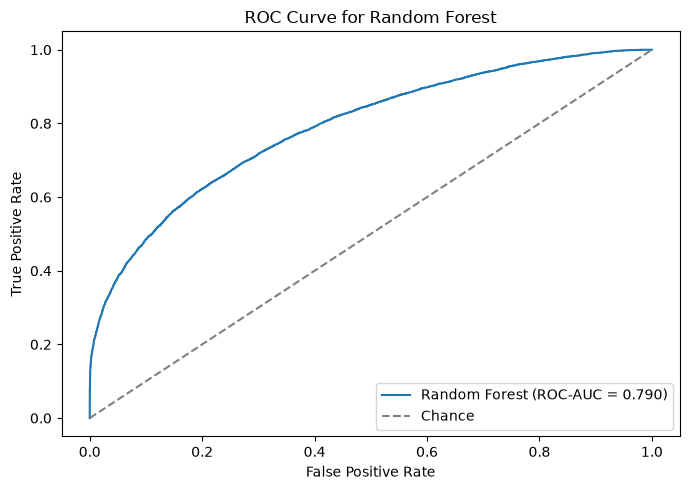

In [13]:
#plot random forest roc curve
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_test_probability)
rf_roc_auc = roc_auc_score(y_test, rf_test_probability)

plt.figure(figsize=(7, 5))
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (ROC-AUC = {rf_roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Random Forest")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(random_forest_output_path / "t3_3_random_forest_roc_curve.png", dpi=300)
plt.show()

**Precision-recall curve**

The precision-recall curve is retained because the readmission outcome is imbalanced.

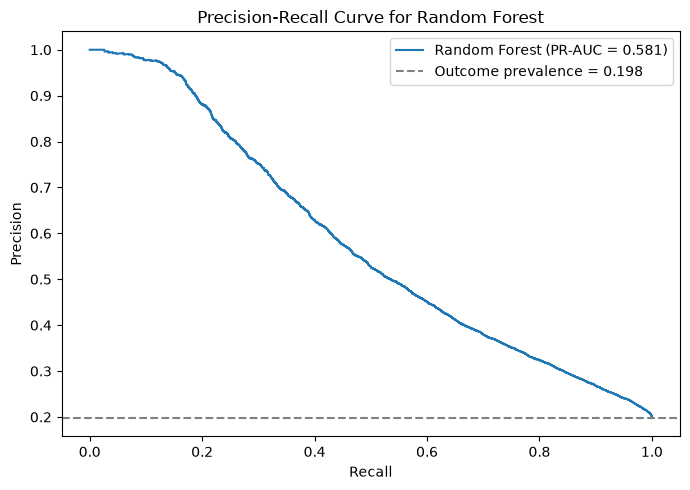

In [ ]:
#plot random forest precision-recall curve
rf_precision, rf_recall, _ = precision_recall_curve(y_test, rf_test_probability)
rf_pr_auc = average_precision_score(y_test, rf_test_probability)
base_rate = y_test.mean()

plt.figure(figsize=(7, 5))
plt.plot(rf_recall, rf_precision, label=f"Random Forest (PR-AUC = {rf_pr_auc:.3f})")
plt.axhline(base_rate, linestyle="--", color="grey", label=f"Outcome prevalence = {base_rate:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Random Forest")
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig(random_forest_output_path / "t3_3_random_forest_precision_recall_curve.png", dpi=300)
plt.show()

**Calibration curve**

Calibration is evaluated for comparison with logistic regression, although Random Forest probabilities are often less well calibrated without additional calibration methods.

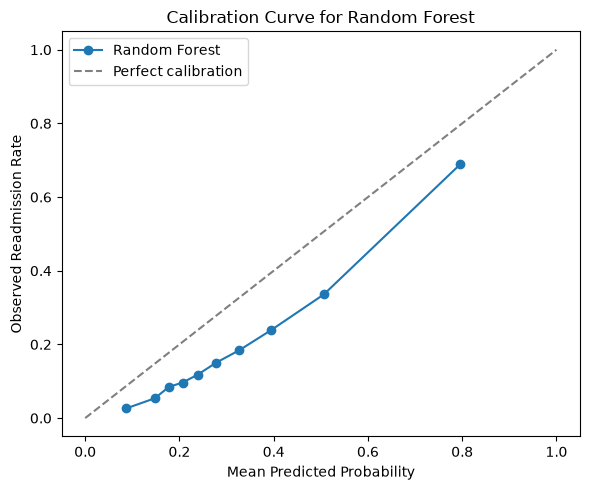

   mean_predicted_probability  observed_readmission_rate
0                      0.0865                     0.0261
1                      0.1476                     0.0536
2                      0.1777                     0.0846
3                      0.2065                     0.0965
4                      0.2385                     0.1177
5                      0.2777                     0.1503
6                      0.3273                     0.1844
7                      0.3934                     0.2379
8                      0.5063                     0.3356
9                      0.7958                     0.6890


In [ ]:
#evaluate random forest calibration using quantile bins
rf_prob_true, rf_prob_pred = calibration_curve(y_test, rf_test_probability, n_bins=10, strategy="quantile")
rf_calibration_df = pd.DataFrame({"mean_predicted_probability": rf_prob_pred,
    "observed_readmission_rate": rf_prob_true})
rf_calibration_df.to_csv(random_forest_output_path / "t3_3_random_forest_calibration_table.csv", index=False)

plt.figure(figsize=(6, 5))
plt.plot(rf_prob_pred, rf_prob_true, marker="o", label="Random Forest")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Perfect calibration")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Readmission Rate")
plt.title("Calibration Curve for Random Forest")
plt.legend(loc="upper left")
plt.tight_layout()
plt.savefig(random_forest_output_path / "t3_3_random_forest_calibration_curve.png", dpi=300)
plt.show()
print(rf_calibration_df.round(4))

**Random Forest feature importance**

Feature importance is saved as a model-specific importance table. These importances should be interpreted as Random Forest importance scores, not causal effects.

In [16]:
#summarise random forest feature importances
rf_importance_df = pd.DataFrame({"processed_feature_name": feature_names,
    "feature_importance": random_forest_model.feature_importances_}).sort_values("feature_importance", ascending=False)
rf_importance_df.to_csv(random_forest_output_path / "t3_3_random_forest_feature_importance.csv", index=False)

print("Top 30 Random Forest features by importance:")
print(rf_importance_df.head(30))

Top 30 Random Forest features by importance:
                                processed_feature_name  feature_importance
227                num__previous_psych_admissions_365d            0.018816
223                num__previous_psych_admissions_180d            0.018661
854           num__late_order_intensity_score_last_12h            0.011832
724  num__late_orders_without_prior_psych_history_flag            0.011814
763                  num__low_late_order_activity_flag            0.008967
350              num__orders_last_12h_before_discharge            0.008730
916     cat__discharge_location_Unknown / not modelled            0.008532
358       num__last_order_within_12h_of_discharge_flag            0.008315
835         num__mostly_psych_readmission_pattern_flag            0.008279
222                num__previous_total_admissions_180d            0.007987
393  num__discontinued_orders_last_12h_before_disch...            0.007770
782  num__care_team_touchpoints_last_12h_before_dis... 

In [ ]:
#summarise lowest random forest feature importances
rf_low_importance_df = rf_importance_df.sort_values("feature_importance", ascending=True).copy()
rf_zero_importance_df = rf_low_importance_df[
    rf_low_importance_df["feature_importance"] == 0].copy()

rf_near_zero_importance_df = rf_low_importance_df[
    rf_low_importance_df["feature_importance"] < 0.00001].copy()

rf_low_importance_df.head(100).to_csv(
    random_forest_output_path / "t3_3_random_forest_lowest_feature_importance.csv",
    index=False)

rf_zero_importance_df.to_csv(
    random_forest_output_path / "t3_3_random_forest_zero_feature_importance.csv", index=False)

rf_near_zero_importance_df.to_csv(
    random_forest_output_path / "t3_3_random_forest_near_zero_feature_importance.csv",index=False)

print("Lowest 30 Random Forest features by importance:")
print(rf_low_importance_df.head(30))

print("\nNumber of zero-importance features:")
print(len(rf_zero_importance_df))

print("\nNumber of near-zero-importance features < 0.00001:")
print(len(rf_near_zero_importance_df))

print("\nLowest-importance feature files saved:")
print(random_forest_output_path / "t3_3_random_forest_lowest_feature_importance.csv")
print(random_forest_output_path / "t3_3_random_forest_zero_feature_importance.csv")
print(random_forest_output_path / "t3_3_random_forest_near_zero_feature_importance.csv")

Lowest 30 Random Forest features by importance:
                                processed_feature_name  feature_importance
941        cat__last_careunit_before_discharge_UNKNOWN        0.000000e+00
450                 num__num_dosing_by_pharmacy_orders        0.000000e+00
447                num__num_unverified_pharmacy_orders        0.000000e+00
526                    num__emar_had_iv_administration        0.000000e+00
550                    num__num_paused_procedureevents        0.000000e+00
753  num__psych_facility_discharge_and_safety_order...        0.000000e+00
867         num__late_psych_safety_home_discharge_flag        7.130763e-19
368          num__self_harm_and_late_safety_order_flag        5.199762e-07
911             cat__discharge_location_OTHER FACILITY        7.202021e-07
725  num__late_orders_and_psych_facility_discharge_...        1.342067e-06
398              num__had_substance_use_followup_order        1.781878e-06
845    num__tachycardia_last_24h_before_discharge_fl

**Random Forest output workbook**

All Random Forest tables are combined into one workbook with separate sheets for easier review.

In [18]:
#save random forest tables into one excel workbook
rf_workbook = random_forest_output_path / "t3_3_random_forest_tables.xlsx"
with pd.ExcelWriter(rf_workbook) as writer:
    rf_performance_df.to_excel(writer, sheet_name="performance", index=False)
    rf_confusion_df.to_excel(writer, sheet_name="confusion_matrices", index=False)
    rf_test_threshold_comparison_df.to_excel(writer, sheet_name="test_thresholds", index=False)
    rf_threshold_table.to_excel(writer, sheet_name="threshold_search", index=False)
    #rf_screening_df.to_excel(writer, sheet_name="hyperparameter_screening", index=false)
    rf_calibration_df.to_excel(writer, sheet_name="calibration", index=False)
    rf_importance_df.to_excel(writer, sheet_name="feature_importance", index=False)

print("Saved Random Forest workbook to:")
print(rf_workbook)

Saved Random Forest workbook to:
/scratch/DissProject/outputs/WP3_3/random_forest/t3_3_random_forest_tables.xlsx


**Regularised Random Forest sensitivity experiment**

A second Random Forest model is trained from a stricter version of the best first-stage Random Forest configuration. This keeps the sensitivity model linked to the selected tuning result while reducing tree complexity to test whether stronger regularisation narrows the training-test performance gap.



In [ ]:
#train a more regularised random forest sensitivity model without overwriting the main tuned model
#the config is derived from the best rf screening result, then made stricter to reduce overfitting.
def make_regularised_rf_config(best_config):
    regularised_config = best_config.copy()

    #keep tree count close to the selected model, but avoid making the sensitivity model slower than the main model.
    regularised_config["n_estimators"] = int(min(max(regularised_config.get("n_estimators", 250), 250), 400))

    #shallower trees and larger leaves reduce model variance.
    selected_max_depth = regularised_config.get("max_depth", 24)
    if selected_max_depth is None:
        regularised_config["max_depth"] = 18
    else:
        regularised_config["max_depth"] = int(max(8, min(selected_max_depth, 18)))

    selected_leaf_size = int(regularised_config.get("min_samples_leaf", 10))
    regularised_config["min_samples_leaf"] = int(max(selected_leaf_size, 20))

    selected_split_size = int(regularised_config.get("min_samples_split", 10))
    regularised_config["min_samples_split"] = int(max(selected_split_size, regularised_config["min_samples_leaf"] * 2, 10))

    #use a smaller feature subset at each split where possible.
    selected_max_features = regularised_config.get("max_features", 0.2)
    if isinstance(selected_max_features, (int, float)):
        regularised_config["max_features"] = float(min(selected_max_features, 0.2))
    else:
        regularised_config["max_features"] = 0.2

    #carry over split criterion and bootstrap choice from the selected model unless unavailable.
    regularised_config["criterion"] = regularised_config.get("criterion", "entropy")
    regularised_config["bootstrap"] = regularised_config.get("bootstrap", True)
    return regularised_config

regularised_rf_config = make_regularised_rf_config(best_rf_config)
regularised_rf_config_df = pd.DataFrame([{"setting": key, "value": value} for key, value in regularised_rf_config.items()])
regularised_rf_config_df.to_csv(
    regularised_random_forest_output_path / "t3_3_regularised_random_forest_derived_config.csv", index=False)

regularised_random_forest_model = RandomForestClassifier(**regularised_rf_config,
    class_weight="balanced_subsample", random_state=42, n_jobs=-1, verbose=2)

print("Best Random Forest configuration used as source:")
print(best_rf_config)
print()
print("Derived regularised Random Forest configuration:")
print(regularised_rf_config)

print("Training regularised Random Forest sensitivity model on full training data...")
regularised_rf_training_start = time.perf_counter()
#fit the model on the current training data
regularised_random_forest_model.fit(X_train, y_train)
regularised_rf_training_time_seconds = time.perf_counter() - regularised_rf_training_start
print("Regularised Random Forest training complete.")

regularised_rf_train_prediction_start = time.perf_counter()
#score admissions as predicted readmission probabilities
regularised_rf_train_probability = regularised_random_forest_model.predict_proba(X_train)[:, 1]
regularised_rf_train_inference_time_seconds = time.perf_counter() - regularised_rf_train_prediction_start

regularised_rf_test_prediction_start = time.perf_counter()
regularised_rf_test_probability = regularised_random_forest_model.predict_proba(X_test)[:, 1]
regularised_rf_test_inference_time_seconds = time.perf_counter() - regularised_rf_test_prediction_start

print("Training ROC-AUC:", round(roc_auc_score(y_train, regularised_rf_train_probability), 4))
print("Test ROC-AUC:", round(roc_auc_score(y_test, regularised_rf_test_probability), 4))
print("Training PR-AUC:", round(average_precision_score(y_train, regularised_rf_train_probability), 4))
print("Test PR-AUC:", round(average_precision_score(y_test, regularised_rf_test_probability), 4))
print("Training time in seconds:", round(regularised_rf_training_time_seconds, 2))
print("Test inference time in seconds:", round(regularised_rf_test_inference_time_seconds, 4))
print("Test inference time per admission in ms:", round((regularised_rf_test_inference_time_seconds / len(y_test)) * 1000, 6))

Best Random Forest configuration used as source:
{'n_estimators': 400, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 0.1, 'max_depth': 24, 'criterion': 'entropy', 'bootstrap': True}

Derived regularised Random Forest configuration:
{'n_estimators': 400, 'min_samples_split': 40, 'min_samples_leaf': 20, 'max_features': 0.1, 'max_depth': 18, 'criterion': 'entropy', 'bootstrap': True}
Training regularised Random Forest sensitivity model on full training data...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 32 concurrent workers.


building tree 1 of 400
building tree 2 of 400
building tree 3 of 400
building tree 4 of 400
building tree 5 of 400
building tree 6 of 400
building tree 7 of 400
building tree 8 of 400
building tree 9 of 400
building tree 10 of 400
building tree 11 of 400
building tree 12 of 400
building tree 13 of 400
building tree 14 of 400
building tree 15 of 400
building tree 16 of 400
building tree 17 of 400
building tree 18 of 400
building tree 19 of 400
building tree 20 of 400
building tree 21 of 400
building tree 22 of 400
building tree 23 of 400
building tree 24 of 400
building tree 25 of 400
building tree 26 of 400
building tree 27 of 400
building tree 28 of 400
building tree 29 of 400
building tree 30 of 400
building tree 31 of 400
building tree 32 of 400
building tree 33 of 400
building tree 34 of 400
building tree 35 of 400
building tree 36 of 400
building tree 37 of 400
building tree 38 of 400
building tree 39 of 400
building tree 40 of 400
building tree 41 of 400
building tree 42 of 400
b

[Parallel(n_jobs=-1)]: Done  98 tasks      | elapsed:  4.3min


building tree 131 of 400
building tree 132 of 400
building tree 133 of 400
building tree 134 of 400
building tree 135 of 400
building tree 136 of 400
building tree 137 of 400
building tree 138 of 400
building tree 139 of 400
building tree 140 of 400
building tree 141 of 400
building tree 142 of 400
building tree 143 of 400
building tree 144 of 400
building tree 145 of 400
building tree 146 of 400
building tree 147 of 400
building tree 148 of 400
building tree 149 of 400
building tree 150 of 400
building tree 151 of 400
building tree 152 of 400
building tree 153 of 400
building tree 154 of 400
building tree 155 of 400
building tree 156 of 400
building tree 157 of 400
building tree 158 of 400
building tree 159 of 400
building tree 160 of 400
building tree 161 of 400
building tree 162 of 400
building tree 163 of 400
building tree 164 of 400
building tree 165 of 400
building tree 166 of 400
building tree 167 of 400
building tree 168 of 400
building tree 169 of 400
building tree 170 of 400


...

[Parallel(n_jobs=-1)]: Done 400 out of 400 | elapsed: 14.6min finished


Regularised Random Forest training complete.


[Parallel(n_jobs=32)]: Using backend ThreadingBackend with 32 concurrent workers.
[Parallel(n_jobs=32)]: Done  98 tasks      | elapsed:    1.1s
[Parallel(n_jobs=32)]: Done 301 tasks      | elapsed:    4.1s
[Parallel(n_jobs=32)]: Done 400 out of 400 | elapsed:    5.2s finished
[Parallel(n_jobs=32)]: Using backend ThreadingBackend with 32 concurrent workers.
[Parallel(n_jobs=32)]: Done  98 tasks      | elapsed:    0.3s
[Parallel(n_jobs=32)]: Done 301 tasks      | elapsed:    0.9s


Training ROC-AUC: 0.9159
Test ROC-AUC: 0.789
Training PR-AUC: 0.7583
Test PR-AUC: 0.5798
Training time in seconds: 879.32
Test inference time in seconds: 1.2023
Test inference time per admission in ms: 0.025489


[Parallel(n_jobs=32)]: Done 400 out of 400 | elapsed:    1.1s finished


**Regularised Random Forest threshold selection**

Thresholds are selected and compared in the same way as the main Random Forest model. Training-set threshold selection remains separate from the held-out test threshold sweep.




In [20]:
#select thresholds for the regularised random forest using training-set predictions
regularised_rf_threshold_table, regularised_rf_best_f1_threshold, regularised_rf_best_youden_threshold = find_best_threshold(
    y_train, regularised_rf_train_probability)
regularised_rf_balanced_pr_threshold = float(regularised_rf_threshold_table.sort_values(
    ["precision_recall_gap", "f1_score"], ascending=[True, False]).iloc[0]["threshold"])
regularised_rf_threshold_table.to_csv(
    regularised_random_forest_output_path / "t3_3_regularised_random_forest_threshold_search_training.csv", index=False)

print("Best regularised Random Forest threshold by F1:", round(regularised_rf_best_f1_threshold, 2))
print("Best regularised Random Forest threshold by Youden index:", round(regularised_rf_best_youden_threshold, 2))
print("Balanced regularised Random Forest precision-recall threshold:", round(regularised_rf_balanced_pr_threshold, 2))
print("\nTop regularised Random Forest threshold rows by F1:")
print(regularised_rf_threshold_table.sort_values("f1_score", ascending=False).head(10))

Best regularised Random Forest threshold by F1: 0.49
Best regularised Random Forest threshold by Youden index: 0.43
Balanced regularised Random Forest precision-recall threshold: 0.53

Top regularised Random Forest threshold rows by F1:
    threshold  precision  recall_sensitivity  precision_recall_gap  f1_score  \
48       0.49   0.635672            0.749441              0.113769  0.687885   
47       0.48   0.622382            0.767265              0.144883  0.687271   
49       0.50   0.647904            0.730172              0.082268  0.686582   
46       0.47   0.609200            0.783669              0.174469  0.685508   
50       0.51   0.660115            0.711638              0.051523  0.684909   
45       0.46   0.594723            0.799942              0.205219  0.682234   
51       0.52   0.671244            0.692579              0.021334  0.681745   
52       0.53   0.682797            0.673624              0.009172  0.678180   
44       0.45   0.580310            0.81445

**Evaluate regularised Random Forest on the held-out test set**

This cell saves the main held-out performance table for the regularised model, including runtime values so it can be compared with the tuned Random Forest.




In [ ]:
#evaluate regularised random forest on the held-out patient-level test set
regularised_rf_timing_kwargs = {"training_time_seconds": regularised_rf_training_time_seconds,
    "train_inference_time_seconds": regularised_rf_train_inference_time_seconds,
    "test_inference_time_seconds": regularised_rf_test_inference_time_seconds,
    "number_of_test_admissions": len(y_test)}

regularised_rf_default_metrics = evaluate_binary_predictions(
    "Regularised Random Forest default threshold", y_test, regularised_rf_test_probability, threshold=0.50)
regularised_rf_f1_metrics = evaluate_binary_predictions(
    "Regularised Random Forest training F1 threshold", y_test, regularised_rf_test_probability, threshold=regularised_rf_best_f1_threshold)
regularised_rf_youden_metrics = evaluate_binary_predictions(
    "Regularised Random Forest training Youden threshold", y_test, regularised_rf_test_probability, threshold=regularised_rf_best_youden_threshold)
regularised_rf_balanced_pr_metrics = evaluate_binary_predictions(
    "Regularised Random Forest balanced precision-recall threshold", y_test, regularised_rf_test_probability, threshold=regularised_rf_balanced_pr_threshold)
regularised_rf_recall_metrics = evaluate_binary_predictions(
    "Regularised Random Forest recall-oriented threshold", y_test, regularised_rf_test_probability, threshold=0.30)

regularised_rf_performance_rows = [add_timing_metrics(regularised_rf_default_metrics, **regularised_rf_timing_kwargs),
    add_timing_metrics(regularised_rf_f1_metrics, **regularised_rf_timing_kwargs),
    add_timing_metrics(regularised_rf_youden_metrics, **regularised_rf_timing_kwargs),
    add_timing_metrics(regularised_rf_balanced_pr_metrics, **regularised_rf_timing_kwargs),
    add_timing_metrics(regularised_rf_recall_metrics, **regularised_rf_timing_kwargs)]

regularised_rf_performance_df = pd.DataFrame(regularised_rf_performance_rows).round(4)
regularised_rf_performance_df.to_csv(
    regularised_random_forest_output_path / "t3_3_regularised_random_forest_performance.csv", index=False)

print("Regularised Random Forest performance:")
print(regularised_rf_performance_df)

Regularised Random Forest performance:
                                               model  threshold  accuracy  \
0        Regularised Random Forest default threshold       0.50    0.8045   
1    Regularised Random Forest training F1 threshold       0.49    0.7998   
2  Regularised Random Forest training Youden thre...       0.43    0.7587   
3  Regularised Random Forest balanced precision-r...       0.53    0.8161   
4  Regularised Random Forest recall-oriented thre...       0.30    0.5919   

   balanced_accuracy  precision  recall_sensitivity  specificity  f1_score  \
0             0.7010     0.5050              0.5298       0.8721    0.5171   
1             0.7030     0.4939              0.5430       0.8630    0.5173   
2             0.7113     0.4256              0.6330       0.7896    0.5090   
3             0.6916     0.5384              0.4858       0.8975    0.5107   
4             0.6826     0.3049              0.8326       0.5327    0.4463   

   roc_auc  pr_auc_average_pr

**Regularised Random Forest held-out threshold comparison**

A held-out threshold sweep is saved to show the precision, recall, specificity, F1, and balanced accuracy trade-off across clinically relevant probability thresholds.




In [ ]:
#compare clinically relevant probability thresholds for the regularised random forest
regularised_test_threshold_values = [0.10, 0.15, 0.20, 0.25, 0.26, 0.27, 0.28, 0.29, 0.30,
    0.31, 0.32, 0.33, 0.34, 0.35, 0.40, 0.45,
    regularised_rf_best_youden_threshold, regularised_rf_best_f1_threshold, 0.50]

regularised_test_threshold_values = sorted(set([round(float(threshold), 2) for threshold in regularised_test_threshold_values]))
regularised_rf_test_threshold_rows = []
for threshold in regularised_test_threshold_values:
    y_pred = (regularised_rf_test_probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    regularised_rf_test_threshold_rows.append({"threshold": threshold,
        "true_negatives": tn, "false_positives": fp,
        "false_negatives": fn, "true_positives": tp,
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall_sensitivity": sensitivity,
        "specificity": specificity, "f1_score": f1_score(y_test, y_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred)})

regularised_rf_test_threshold_comparison_df = pd.DataFrame(regularised_rf_test_threshold_rows).sort_values("threshold")
regularised_rf_test_threshold_comparison_df.to_csv(
    regularised_random_forest_output_path / "t3_3_regularised_random_forest_test_threshold_comparison.csv", index=False)
regularised_rf_heldout_f1_threshold = regularised_rf_test_threshold_comparison_df.sort_values("f1_score", ascending=False).iloc[0]["threshold"]

print("Held-out test threshold comparison for regularised Random Forest:")
print(regularised_rf_test_threshold_comparison_df.round(4))
print("\nBest held-out F1 threshold for regularised Random Forest:", round(regularised_rf_heldout_f1_threshold, 2))
print("\nRegularised Random Forest selected threshold comparison:")
print(regularised_rf_test_threshold_comparison_df[
    regularised_rf_test_threshold_comparison_df["threshold"].isin([
        round(regularised_rf_heldout_f1_threshold, 2), 0.30, round(regularised_rf_best_youden_threshold, 2), 0.50])].round(4))

Held-out test threshold comparison for regularised Random Forest:
    threshold  true_negatives  false_positives  false_negatives  \
0        0.10            1350            36502                5   
1        0.15            3425            34427               72   
2        0.20            8229            29623              353   
3        0.25           14458            23394              898   
4        0.26           15704            22148              996   
5        0.27           16867            20985             1128   
6        0.28           18041            19811             1281   
7        0.29           19108            18744             1432   
8        0.30           20163            17689             1560   
9        0.31           21177            16675             1712   
10       0.32           22068            15784             1859   
11       0.33           22925            14927             1986   
12       0.34           23728            14124             2107

**Save regularised Random Forest predictions and model**

The sensitivity model is saved separately from the main tuned Random Forest model.




In [ ]:
#save regularised random forest model and held-out test predictions
regularised_rf_predictions = save_prediction_file(regularised_random_forest_output_path,
    "t3_3_regularised_random_forest_test_predictions.csv", test_ids,
    regularised_rf_test_probability, regularised_rf_best_youden_threshold)

joblib.dump(regularised_random_forest_model,
    regularised_random_forest_output_path / "t3_3_regularised_random_forest_model.joblib")

print("Saved regularised Random Forest model and predictions to:")
print(regularised_random_forest_output_path)
print("\nPrediction preview:")
print(regularised_rf_predictions.head())

Saved regularised Random Forest model and predictions to:
/scratch/DissProject/outputs/WP3_3/regularised_random_forest

Prediction preview:
   subject_id   hadm_id  readmitted_30d  days_to_next  next_is_psych  \
0    10000117  22927623               0         672.0              1   
1    10000117  27988844               0           NaN              0   
2    10002221  21008195               0         984.0              1   
3    10002221  20195471               0         377.0              1   
4    10002221  21729093               1           3.0              1   

   readmitted_30d_psych  readmitted_60d_psych  readmitted_90d_psych  \
0                     0                     0                     0   
1                     0                     0                     0   
2                     0                     0                     0   
3                     0                     0                     0   
4                     1                     1                     1   



**Regularised Random Forest confusion matrix**

Confusion matrices are saved for the default, training-selected, held-out F1, and recall-oriented thresholds.




In [ ]:
#summarise confusion matrix counts for regularised random forest thresholds
if "regularised_rf_balanced_pr_threshold" not in globals():
    saved_regularised_rf_threshold_table = pd.read_csv(
        regularised_random_forest_output_path / "t3_3_regularised_random_forest_threshold_search_training.csv")
    regularised_rf_balanced_pr_threshold = float(saved_regularised_rf_threshold_table.sort_values(
        ["precision_recall_gap", "f1_score"], ascending=[True, False]).iloc[0]["threshold"])

regularised_rf_confusion_thresholds = [("Regularised Random Forest default threshold", 0.50),
    ("Regularised Random Forest training Youden threshold", regularised_rf_best_youden_threshold),
    ("Regularised Random Forest balanced precision-recall threshold", regularised_rf_balanced_pr_threshold),
    ("Regularised Random Forest held-out F1 threshold", regularised_rf_heldout_f1_threshold),
    ("Regularised Random Forest recall-oriented threshold", 0.30)]

regularised_rf_confusion_rows = []
for threshold_name, threshold in regularised_rf_confusion_thresholds:
    y_pred = (regularised_rf_test_probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    regularised_rf_confusion_rows.append({"model": threshold_name, "threshold": threshold,
        "true_negatives": tn, "false_positives": fp, "false_negatives": fn, "true_positives": tp})

regularised_rf_confusion_df = pd.DataFrame(regularised_rf_confusion_rows)
regularised_rf_confusion_df.to_csv(
    regularised_random_forest_output_path / "t3_3_regularised_random_forest_confusion_matrices.csv",index=False)
print(regularised_rf_confusion_df)

                                               model  threshold  \
0        Regularised Random Forest default threshold       0.50   
1  Regularised Random Forest training Youden thre...       0.43   
2  Regularised Random Forest balanced precision-r...       0.53   
3    Regularised Random Forest held-out F1 threshold       0.49   
4  Regularised Random Forest recall-oriented thre...       0.30   

   true_negatives  false_positives  false_negatives  true_positives  
0           33012             4840             4382            4937  
1           29889             7963             3420            5899  
2           33971             3881             4792            4527  
3           32667             5185             4259            5060  
4           20163            17689             1560            7759  


**Regularised Random Forest curves**

ROC, precision-recall, and calibration curves are produced for the regularised sensitivity model using the held-out test set.




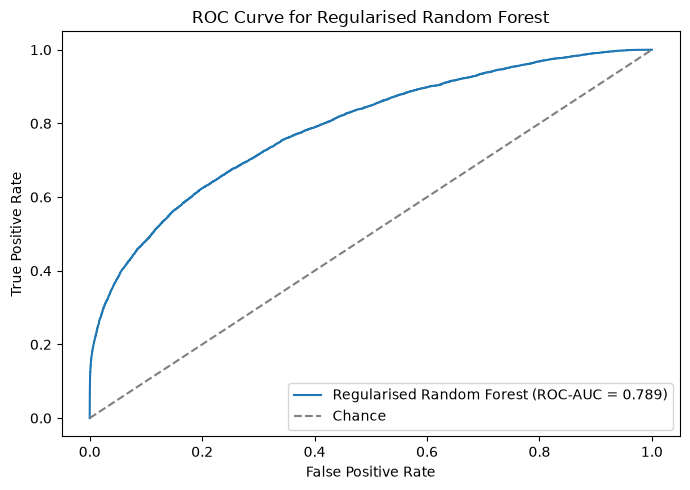

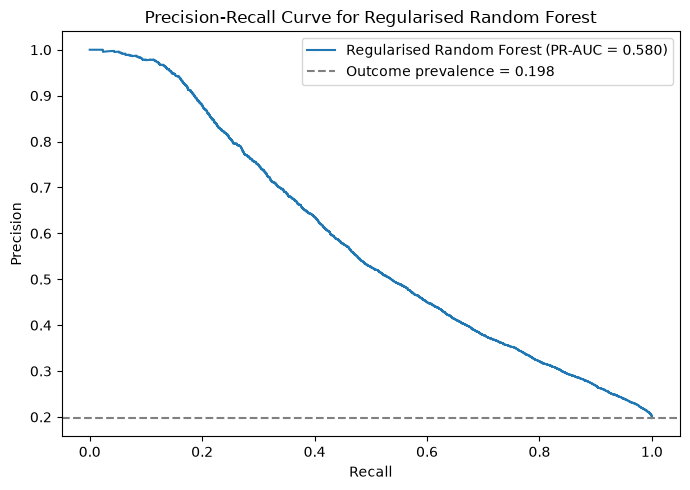

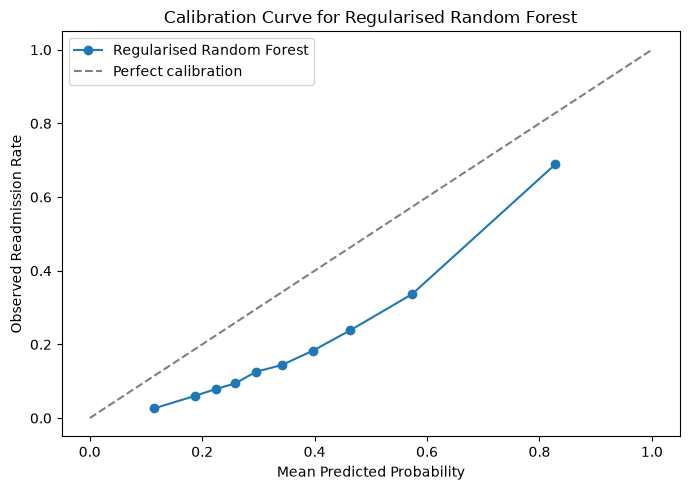

Regularised Random Forest calibration table:
   mean_predicted_probability  observed_readmission_rate
0                      0.1148                     0.0265
1                      0.1871                     0.0602
2                      0.2237                     0.0787
3                      0.2587                     0.0941
4                      0.2960                     0.1259
5                      0.3417                     0.1439
6                      0.3963                     0.1825
7                      0.4629                     0.2379
8                      0.5735                     0.3364
9                      0.8285                     0.6894


In [ ]:
#plot regularised random forest roc, precision-recall, and calibration curves
regularised_rf_fpr, regularised_rf_tpr, _ = roc_curve(y_test, regularised_rf_test_probability)
regularised_rf_roc_auc = roc_auc_score(y_test, regularised_rf_test_probability)

plt.figure(figsize=(7, 5))
plt.plot(regularised_rf_fpr, regularised_rf_tpr, label=f"Regularised Random Forest (ROC-AUC = {regularised_rf_roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Regularised Random Forest")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(regularised_random_forest_output_path / "t3_3_regularised_random_forest_roc_curve.png", dpi=300)
plt.show()

regularised_rf_precision, regularised_rf_recall, _ = precision_recall_curve(y_test, regularised_rf_test_probability)
regularised_rf_pr_auc = average_precision_score(y_test, regularised_rf_test_probability)
base_rate = y_test.mean()

plt.figure(figsize=(7, 5))
plt.plot(regularised_rf_recall, regularised_rf_precision, label=f"Regularised Random Forest (PR-AUC = {regularised_rf_pr_auc:.3f})")
plt.axhline(base_rate, linestyle="--", color="grey", label=f"Outcome prevalence = {base_rate:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Regularised Random Forest")
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig(regularised_random_forest_output_path / "t3_3_regularised_random_forest_precision_recall_curve.png", dpi=300)
plt.show()

regularised_rf_prob_true, regularised_rf_prob_pred = calibration_curve(
    y_test, regularised_rf_test_probability, n_bins=10, strategy="quantile")
regularised_rf_calibration_df = pd.DataFrame({"mean_predicted_probability": regularised_rf_prob_pred,
    "observed_readmission_rate": regularised_rf_prob_true}).round(4)
regularised_rf_calibration_df.to_csv(
    regularised_random_forest_output_path / "t3_3_regularised_random_forest_calibration_table.csv",index=False)

plt.figure(figsize=(7, 5))
plt.plot(regularised_rf_prob_pred, regularised_rf_prob_true, marker="o", label="Regularised Random Forest")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Perfect calibration")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Readmission Rate")
plt.title("Calibration Curve for Regularised Random Forest")
plt.legend(loc="upper left")
plt.tight_layout()
plt.savefig(regularised_random_forest_output_path / "t3_3_regularised_random_forest_calibration_curve.png", dpi=300)
plt.show()

print("Regularised Random Forest calibration table:")
print(regularised_rf_calibration_df)

**Regularised Random Forest feature importance**

Feature importance is saved for the regularised sensitivity model and can be compared with the main tuned Random Forest importance table.




In [ ]:
#summarise regularised random forest feature importances
regularised_rf_importance_df = pd.DataFrame({"processed_feature_name": feature_names,
    "feature_importance": regularised_random_forest_model.feature_importances_}).sort_values("feature_importance", ascending=False)
regularised_rf_importance_df.to_csv(
    regularised_random_forest_output_path / "t3_3_regularised_random_forest_feature_importance.csv",index=False)

print("Top 30 regularised Random Forest features by importance:")
print(regularised_rf_importance_df.head(30))

Top 30 regularised Random Forest features by importance:
                                processed_feature_name  feature_importance
227                num__previous_psych_admissions_365d            0.028585
223                num__previous_psych_admissions_180d            0.027489
724  num__late_orders_without_prior_psych_history_flag            0.017892
854           num__late_order_intensity_score_last_12h            0.016134
763                  num__low_late_order_activity_flag            0.013951
916     cat__discharge_location_Unknown / not modelled            0.012646
358       num__last_order_within_12h_of_discharge_flag            0.012139
350              num__orders_last_12h_before_discharge            0.011602
835         num__mostly_psych_readmission_pattern_flag            0.011464
245                           num__admissions_per_365d            0.010680
222                num__previous_total_admissions_180d            0.010621
393  num__discontinued_orders_last_12h_befo

**Random Forest sensitivity comparison**

The main tuned Random Forest and the regularised sensitivity model are compared directly on held-out test-set performance and generalisation gap.




In [ ]:
#compare main tuned random forest with the regularised sensitivity model
main_rf_performance_file = random_forest_output_path / "t3_3_random_forest_performance.csv"
main_rf_performance_for_comparison = pd.read_csv(main_rf_performance_file)
main_rf_performance_for_comparison.insert(0, "model_family", "Main tuned Random Forest")

regularised_rf_performance_for_comparison = regularised_rf_performance_df.copy()
regularised_rf_performance_for_comparison.insert(0, "model_family", "Regularised Random Forest")

rf_sensitivity_comparison_df = pd.concat(
    [main_rf_performance_for_comparison, regularised_rf_performance_for_comparison], ignore_index=True)
rf_sensitivity_comparison_df.to_csv(
    wp3_3_output_path / "t3_3_random_forest_sensitivity_comparison.csv", index=False)

rf_generalisation_rows = []
if "rf_train_probability" in globals() and "rf_test_probability" in globals():
    rf_generalisation_rows.append({"model": "Main tuned Random Forest",
        "training_roc_auc": roc_auc_score(y_train, rf_train_probability),
        "test_roc_auc": roc_auc_score(y_test, rf_test_probability),
        "roc_auc_gap": roc_auc_score(y_train, rf_train_probability) - roc_auc_score(y_test, rf_test_probability),
        "training_pr_auc_average_precision": average_precision_score(y_train, rf_train_probability),
        "test_pr_auc_average_precision": average_precision_score(y_test, rf_test_probability),
        "pr_auc_gap": average_precision_score(y_train, rf_train_probability) - average_precision_score(y_test, rf_test_probability),
        "test_brier_score": brier_score_loss(y_test, rf_test_probability)})

rf_generalisation_rows.append({"model": "Regularised Random Forest",
    "training_roc_auc": roc_auc_score(y_train, regularised_rf_train_probability),
    "test_roc_auc": roc_auc_score(y_test, regularised_rf_test_probability),
    "roc_auc_gap": roc_auc_score(y_train, regularised_rf_train_probability) - roc_auc_score(y_test, regularised_rf_test_probability),
    "training_pr_auc_average_precision": average_precision_score(y_train, regularised_rf_train_probability),
    "test_pr_auc_average_precision": average_precision_score(y_test, regularised_rf_test_probability),
    "pr_auc_gap": average_precision_score(y_train, regularised_rf_train_probability) - average_precision_score(y_test, regularised_rf_test_probability),
    "test_brier_score": brier_score_loss(y_test, regularised_rf_test_probability)})

rf_generalisation_comparison_df = pd.DataFrame(rf_generalisation_rows).round(4)
rf_generalisation_comparison_df.to_csv(wp3_3_output_path / "t3_3_random_forest_generalisation_comparison.csv", index=False)

print("Random Forest sensitivity comparison:")
print(rf_sensitivity_comparison_df.round(4))
print("\nRandom Forest generalisation comparison:")
print(rf_generalisation_comparison_df)

Random Forest sensitivity comparison:
                model_family  \
0   Main tuned Random Forest   
1   Main tuned Random Forest   
2   Main tuned Random Forest   
3   Main tuned Random Forest   
4   Main tuned Random Forest   
5  Regularised Random Forest   
6  Regularised Random Forest   
7  Regularised Random Forest   
8  Regularised Random Forest   
9  Regularised Random Forest   

                                               model  threshold  accuracy  \
0                                      Random Forest       0.50    0.8274   
1                                      Random Forest       0.47    0.8193   
2                                      Random Forest       0.42    0.8004   
3  Random Forest balanced precision-recall threshold       0.51    0.8296   
4                                      Random Forest       0.29    0.6764   
5        Regularised Random Forest default threshold       0.50    0.8045   
6    Regularised Random Forest training F1 threshold       0.49    0.7

**Combined Random Forest discrimination curves**

The ROC and precision-recall curves are combined into one two-panel figure to compare the main tuned Random Forest with the regularised sensitivity model.




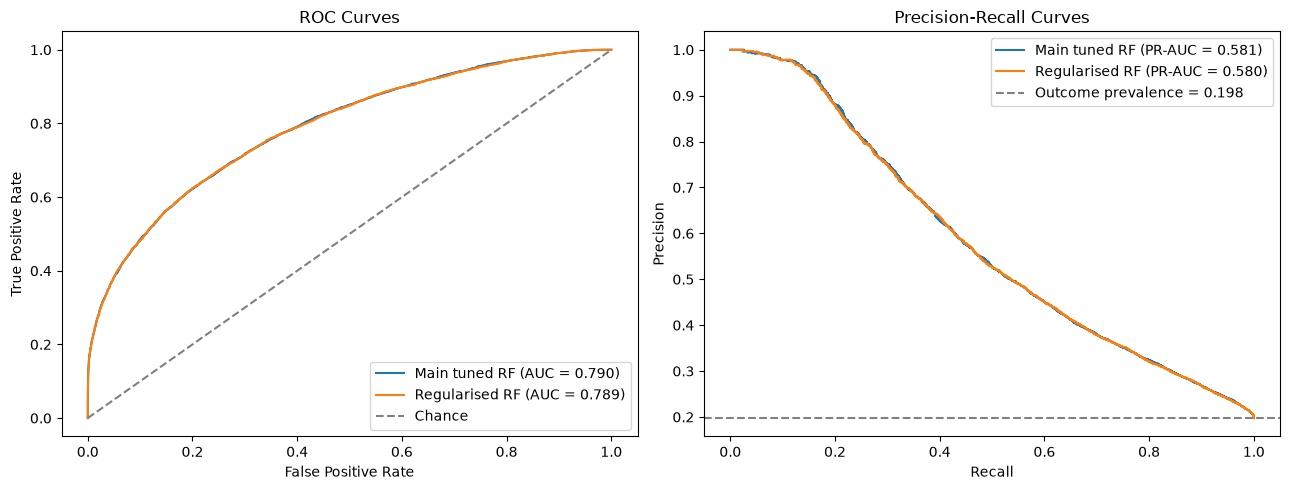

Saved combined Random Forest discrimination curves to:
/scratch/DissProject/outputs/WP3_3/t3_3_random_forest_combined_discrimination_curves.png


In [ ]:
#create a publication-style two-panel discrimination figure comparing both random forest variants
if "rf_test_probability" not in globals():
    rf_saved_predictions = pd.read_csv(random_forest_output_path / "t3_3_random_forest_test_predictions.csv")
    rf_test_probability = rf_saved_predictions["predicted_probability"]

if "regularised_rf_test_probability" not in globals():
    regularised_rf_saved_predictions = pd.read_csv(
        regularised_random_forest_output_path / "t3_3_regularised_random_forest_test_predictions.csv")
    regularised_rf_test_probability = regularised_rf_saved_predictions["predicted_probability"]

main_rf_fpr, main_rf_tpr, _ = roc_curve(y_test, rf_test_probability)
regularised_rf_fpr, regularised_rf_tpr, _ = roc_curve(y_test, regularised_rf_test_probability)
main_rf_roc_auc = roc_auc_score(y_test, rf_test_probability)
regularised_rf_roc_auc = roc_auc_score(y_test, regularised_rf_test_probability)

main_rf_precision, main_rf_recall, _ = precision_recall_curve(y_test, rf_test_probability)
regularised_rf_precision, regularised_rf_recall, _ = precision_recall_curve(y_test, regularised_rf_test_probability)
main_rf_pr_auc = average_precision_score(y_test, rf_test_probability)
regularised_rf_pr_auc = average_precision_score(y_test, regularised_rf_test_probability)
base_rate = y_test.mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(main_rf_fpr, main_rf_tpr, label=f"Main tuned RF (AUC = {main_rf_roc_auc:.3f})")
axes[0].plot(regularised_rf_fpr, regularised_rf_tpr, label=f"Regularised RF (AUC = {regularised_rf_roc_auc:.3f})")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="grey", label="Chance")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves")
axes[0].legend(loc="lower right")

axes[1].plot(main_rf_recall, main_rf_precision, label=f"Main tuned RF (PR-AUC = {main_rf_pr_auc:.3f})")
axes[1].plot(regularised_rf_recall, regularised_rf_precision, label=f"Regularised RF (PR-AUC = {regularised_rf_pr_auc:.3f})")
axes[1].axhline(base_rate, linestyle="--", color="grey", label=f"Outcome prevalence = {base_rate:.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves")
axes[1].legend(loc="upper right")

plt.tight_layout()
combined_rf_curve_file = wp3_3_output_path / "t3_3_random_forest_combined_discrimination_curves.png"
plt.savefig(combined_rf_curve_file, dpi=300)
plt.show()

print("Saved combined Random Forest discrimination curves to:")
print(combined_rf_curve_file)

**Regularised Random Forest output workbook**

All regularised Random Forest sensitivity tables are combined into one workbook with separate sheets for easier review.




In [ ]:
#save regularised random forest tables into one excel workbook
regularised_rf_workbook = regularised_random_forest_output_path / "t3_3_regularised_random_forest_tables.xlsx"
with pd.ExcelWriter(regularised_rf_workbook) as writer:
    regularised_rf_performance_df.to_excel(writer, sheet_name="performance", index=False)
    regularised_rf_confusion_df.to_excel(writer, sheet_name="confusion_matrices", index=False)
    regularised_rf_test_threshold_comparison_df.to_excel(writer, sheet_name="test_thresholds", index=False)
    regularised_rf_threshold_table.to_excel(writer, sheet_name="threshold_search", index=False)
    regularised_rf_calibration_df.to_excel(writer, sheet_name="calibration", index=False)
    regularised_rf_importance_df.to_excel(writer, sheet_name="feature_importance", index=False)
    rf_sensitivity_comparison_df.to_excel(writer, sheet_name="sensitivity_compare", index=False)
    rf_generalisation_comparison_df.to_excel(writer, sheet_name="generalisation", index=False)

print("Saved regularised Random Forest workbook to:")
print(regularised_rf_workbook)

Saved regularised Random Forest workbook to:
/scratch/DissProject/outputs/WP3_3/regularised_random_forest/t3_3_regularised_random_forest_tables.xlsx


**Final WP3.3 output summary**

This final check confirms the files created for the Random Forest model.

In [ ]:
#list all wp3.3 files created by this notebook
created_files = sorted(wp3_3_output_path.glob("**/t3_3_*"))
summary_df = pd.DataFrame({"output_folder": [path.parent.name for path in created_files],
    "output_file": [path.name for path in created_files],
    "file_size_mb": [round(path.stat().st_size / (1024 ** 2), 3) for path in created_files]})
summary_df.to_csv(wp3_3_output_path / "t3_3_output_file_summary.csv", index=False)

print("WP3.3 output files:")
print(summary_df)
print("\nWP3.3 complete. Outputs saved to:")
print(wp3_3_output_path)

WP3.3 output files:
                output_folder  \
0               random_forest   
1               random_forest   
2               random_forest   
3               random_forest   
4               random_forest   
5               random_forest   
6               random_forest   
7               random_forest   
8               random_forest   
9               random_forest   
10              random_forest   
11              random_forest   
12              random_forest   
13              random_forest   
14              random_forest   
15              random_forest   
16  regularised_random_forest   
17  regularised_random_forest   
18  regularised_random_forest   
19  regularised_random_forest   
20  regularised_random_forest   
21  regularised_random_forest   
22  regularised_random_forest   
23  regularised_random_forest   
24  regularised_random_forest   
25  regularised_random_forest   
26  regularised_random_forest   
27  regularised_random_forest   
28  regularised_random_

**Consolidated CSV Table Workbook**

This cell keeps the individual CSV files and also creates one Excel workbook where each CSV table is available as a separate sheet. The workbook is for easier review and sharing; the CSV files remain the primary machine-readable outputs.


In [ ]:
#compile csv tables into one workbook while preserving the original csv files
possible_output_roots = []
#loop through each item in this feature block
for output_name in ['wp3_3_output_path']:
    if output_name in globals():
        output_root = globals()[output_name]
        if isinstance(output_root, Path) and output_root.exists() and output_root not in possible_output_roots:
            possible_output_roots.append(output_root)

if not possible_output_roots:
    print("no wp3 output roots were available for workbook compilation")
else:
    primary_output_root = possible_output_roots[0]
    workbook_path = primary_output_root / f"{primary_output_root.name.lower()}_csv_table_workbook.xlsx"
    csv_paths = []
    #loop through each item in this feature block
    for output_root in possible_output_roots:
        csv_paths.extend(sorted(path for path in output_root.rglob("*.csv") if path.is_file()))
    csv_paths = sorted(dict.fromkeys(csv_paths))

    #make sheet name
    def make_sheet_name(csv_path, used_names):
        relative_name = csv_path.relative_to(primary_output_root.parent).with_suffix("").as_posix()
        relative_name = re.sub(r"[^0-9a-zA-Z]+", "_", relative_name).strip("_").lower()
        parts = [part for part in relative_name.split("_") if part not in ["outputs", primary_output_root.name.lower(), "csv", "tables"]]
        base_name = "_".join(parts[-4:]) if parts else csv_path.stem.lower()
        base_name = base_name[:31] or "table"
        sheet_name = base_name
        counter = 1
        while sheet_name in used_names:
            suffix = f"_{counter}"
            sheet_name = base_name[:31 - len(suffix)] + suffix
            counter += 1
        used_names.add(sheet_name)
        return sheet_name

    workbook_index_rows = []
    used_sheet_names = set()
    max_excel_rows = 200000
    with pd.ExcelWriter(workbook_path) as writer:
        #loop through each item in this feature block
        for csv_path in csv_paths:
            try:
                table_df = pd.read_csv(csv_path)
            except Exception as error:
                workbook_index_rows.append({"csv_path": str(csv_path), "sheet_name": "", "rows": np.nan,
                    "columns": np.nan, "rows_written": 0, "note": f"read_failed: {error}"})
                continue
            sheet_name = make_sheet_name(csv_path, used_sheet_names)
            rows_written = min(len(table_df), max_excel_rows)
            #save this table or artefact for later review
            table_df.head(max_excel_rows).to_excel(writer, sheet_name=sheet_name, index=False)
            workbook_index_rows.append({"csv_path": str(csv_path), "sheet_name": sheet_name, "rows": len(table_df),
                "columns": table_df.shape[1], "rows_written": rows_written,
                "note": "truncated_for_excel" if len(table_df) > max_excel_rows else "complete"})
        workbook_index_df = pd.DataFrame(workbook_index_rows)
        #save this table or artefact for later review
        workbook_index_df.to_excel(writer, sheet_name="workbook_index", index=False)
    #save this table or artefact for later review
    workbook_index_df.to_csv(primary_output_root / f"{primary_output_root.name.lower()}_csv_table_workbook_index.csv", index=False)
    print("csv table workbook saved to:")
    print(workbook_path)
    display(workbook_index_df)

csv table workbook saved to:
/scratch/DissProject/outputs/WP3_3/wp3_3_csv_table_workbook.xlsx


,csv_path,sheet_name,rows,columns,rows_written,note
0,/scratch/DissProject/outputs/WP3_3/random_fore...,random_forest_calibration_table,10,2,10,complete
1,/scratch/DissProject/outputs/WP3_3/random_fore...,random_forest_confusion_matrice,5,6,5,complete
2,/scratch/DissProject/outputs/WP3_3/random_fore...,random_forest_feature_importanc,973,2,973,complete
3,/scratch/DissProject/outputs/WP3_3/random_fore...,random_forest_hyperparameter_sc,12,14,12,complete
4,/scratch/DissProject/outputs/WP3_3/random_fore...,forest_lowest_feature_importanc,100,2,100,complete
5,/scratch/DissProject/outputs/WP3_3/random_fore...,near_zero_feature_importance,21,2,21,complete
6,/scratch/DissProject/outputs/WP3_3/random_fore...,3_random_forest_performance,5,19,5,complete
7,/scratch/DissProject/outputs/WP3_3/random_fore...,random_forest_test_predictions,47171,15,47171,complete
8,/scratch/DissProject/outputs/WP3_3/random_fore...,forest_test_threshold_compariso,19,10,19,complete
9,/scratch/DissProject/outputs/WP3_3/random_fore...,forest_threshold_search_trainin,99,8,99,complete
